# Lab 7.06 - Time series analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation


## Exercise 6: COVID-19 data


In this lab assignment, we will make use of the COVID-19 dataset maintained by [Our World in Data](https://ourworldindata.org/coronavirus), published on Github at <https://github.com/owid/covid-19-data/tree/master/public/data>.

We took a snapshot of the data on 2023-05-31 that still contains *daily* observations. Recently, the dataset has been updated to only contain weekly observations.

First, we import the dataset, parse the `date` column as the Python `DateTime` type and set this as the index.

**Tip:** The CSV file is rather large, so instead you may want to load a local copy of the CSV file to avoid downloading it multiple times ('../data/owid-covid-data-2023-05-31.csv').

In [2]:
covid19 = pd.read_csv(
    'https://github.com/HoGentTIN/dsai-labs/raw/main/data/owid-covid-data-2023-05-31.csv',
    parse_dates=['date'],
    index_col=['date'])
covid19.head()

,iso_code,continent,location,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-04,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-05,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-06,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-07,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


Create a new `DataFrame` (with name e.g. `covid19_be`) that only contains the new cases in Belgium and use the `plot()` method of `DataFrame` to visualize it. Increase the size of the picture with the `figsize` parameter, otherwise it will be too small.

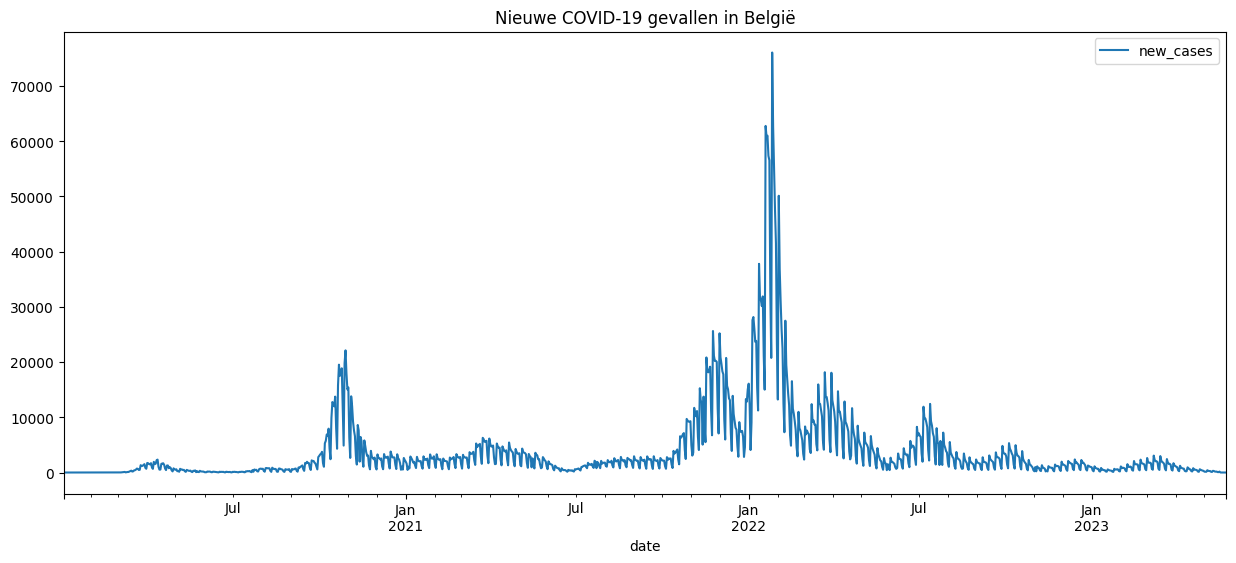

In [3]:
# Selecteer nieuwe gevallen in België
covid19_be = covid19[covid19['location'] == 'Belgium'][['new_cases']].copy()

# Visualisatie
covid19_be.plot(figsize=(15, 6), title='Nieuwe COVID-19 gevallen in België')
plt.show()

### Moving average

Add new columns to the data frame with new cases in Belgium with the simple moving average for 7 and 30 days. Plot the entire data frame (observations and both moving averages).

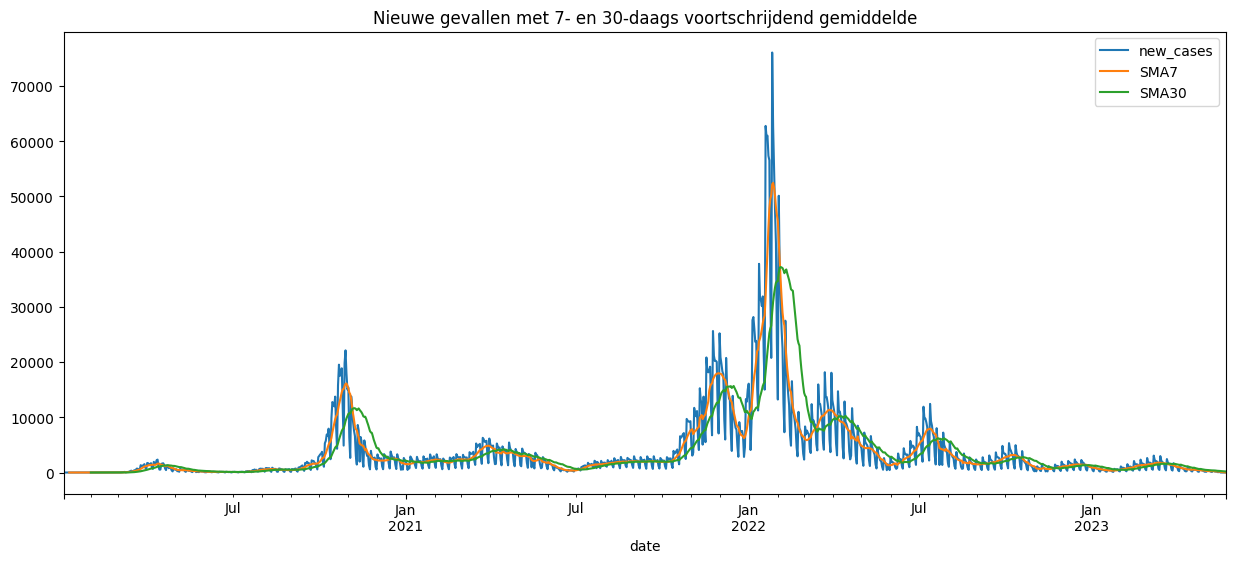

In [4]:
covid19_be['SMA7'] = covid19_be['new_cases'].rolling(7).mean()
covid19_be['SMA30'] = covid19_be['new_cases'].rolling(30).mean()
covid19_be.plot(figsize=(15, 6), title='Nieuwe gevallen met 7- en 30-daags voortschrijdend gemiddelde')
plt.show()

### Holt-Winters model for new cases early 2021

The period from about December 2020 up to the end of February 2021 seems quite regular. Create a new `DataFrame` and select only the observations during that period (1 December 2020 to 28 February 2021). Plot the `DataFrame` (it will still contain the moving averages from the previous step).

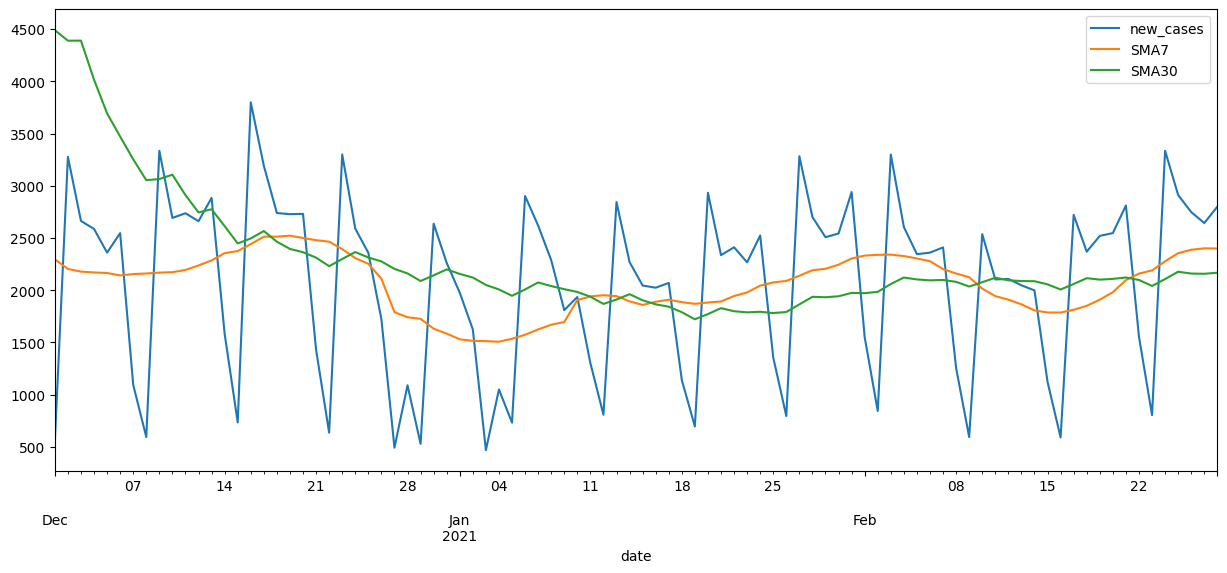

In [5]:
# Selecteer periode
start_date = '2020-12-01'
end_date = '2021-02-28'
covid19_be_2021 = covid19_be.loc[start_date:end_date].copy()

# Plot
covid19_be_2021[['new_cases', 'SMA7', 'SMA30']].plot(figsize=(15, 6))
plt.show()



Build a Holt-Winters model for the observed new cases during that period.

Use the additive type for both trend and seasonal smoothing. Set the value for `seasonal_periods` to the appropriate value! Plot the observed and fitted values.

/home/seppevo/repo/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


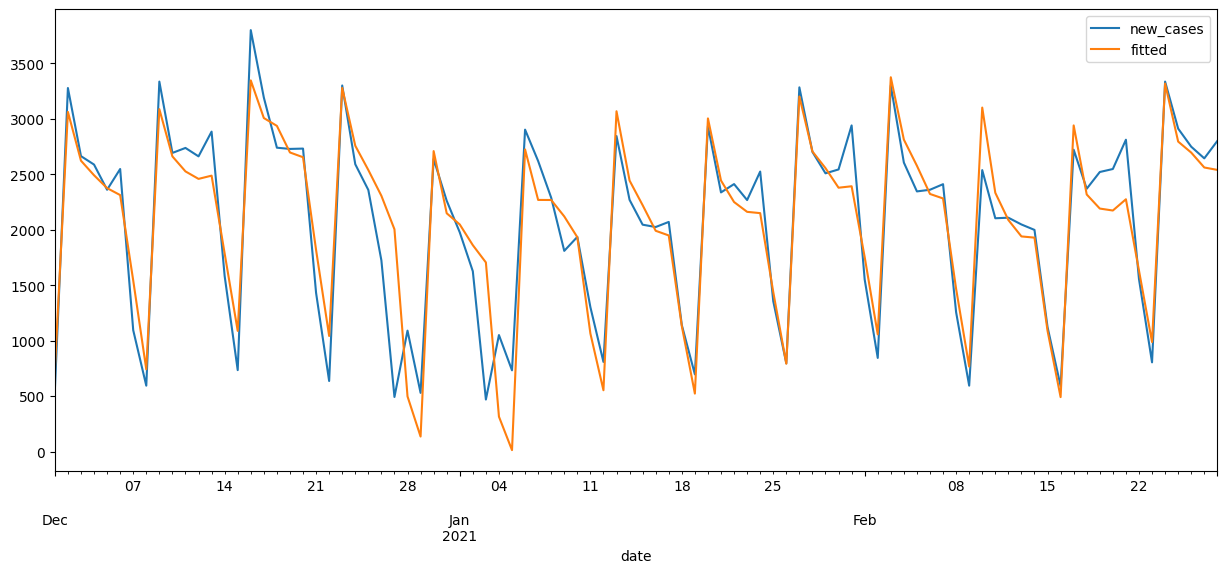

In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Holt-Winters model (additief, periode=7 voor wekelijkse patronen)
model = ExponentialSmoothing(covid19_be_2021['new_cases'], trend='add', seasonal='add', seasonal_periods=7)
fit = model.fit()

# Plot
covid19_be_2021['fitted'] = fit.fittedvalues
covid19_be_2021[['new_cases', 'fitted']].plot(figsize=(15, 6))
plt.show()

Now, make a forecast for 21 days and plot observed and forecasted values. What do you notice when you compare observed and forecasted values as time progresses?

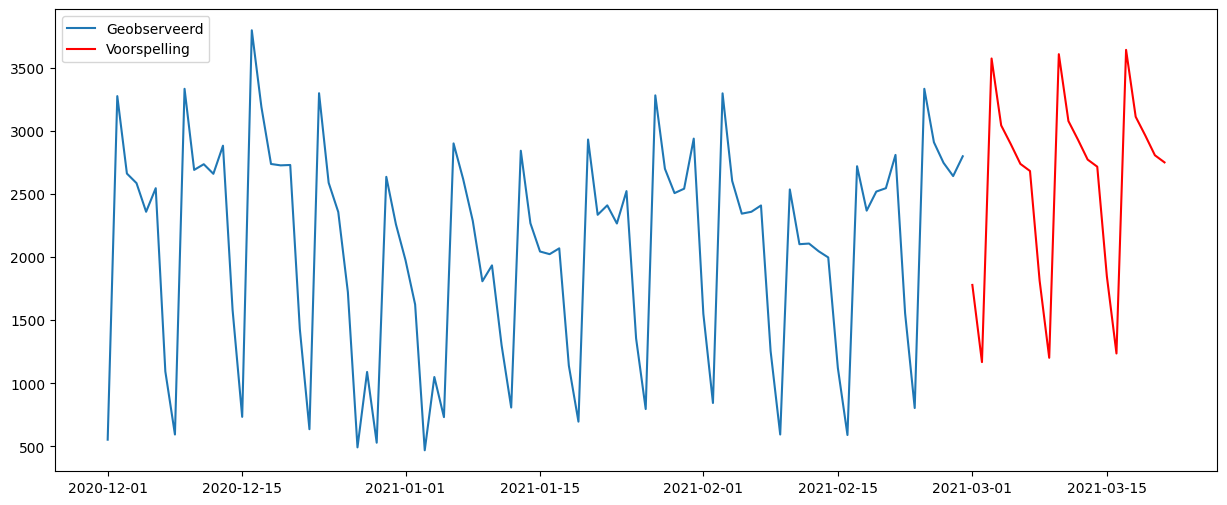

In [7]:
# Voorspelling voor 21 dagen
forecast = fit.forecast(21)

# Plot
plt.figure(figsize=(15, 6))
plt.plot(covid19_be_2021['new_cases'], label='Geobserveerd')
plt.plot(forecast, label='Voorspelling', color='red')
plt.legend()
plt.show()
# Opmerking: Na verloop van tijd wijken voorspellingen vaak af door nieuwe golven of veranderend gedrag.

### Evaluating model quality


- Calculate the Mean Squared Error for a forecast period of 7 days, and compare its square root with the standard deviation of observed new cases over the test period and forecasted period combined.
- Do the same for a forecast period of 14 and 21 days.
- For which period is the quality of the forecast ok?

The expected results are shown in the table below:

|     Forecast period      |         MSE |     √MSE |    stdev |
| :----------------------: | ----------: | -------: | -------: |
| 2021-03-01 to 2021-03-07 |   25408.902 |  159.402 |  855.684 |
| 2021-03-01 to 2021-03-14 |  154280.817 |  392.786 |  895.531 |
| 2021-03-01 to 2021-03-21 | 1048835.781 | 1024.127 | 1052.978 |

In [15]:
# Zorg dat covid19_be je bron is, die bevat enkel de Belgische data
def evaluate_forecast(test_period_end):
    # Gebruik covid19_be in plaats van de volledige covid19 dataset
    test_data = covid19_be.loc['2021-03-01':test_period_end, 'new_cases']
    
    # Voorspel op basis van het eerder getrainde model
    pred = fit.forecast(len(test_data))
    
    mse = mean_squared_error(test_data, pred)
    rmse = np.sqrt(mse)
    
    # Gebruik de data die je al hebt voor de stdev berekening
    combined = pd.concat([covid19_be_2021['new_cases'], test_data])
    stdev = combined.std()
    
    return mse, rmse, stdev

# Resultaten printen (dit zou nu moeten werken)
for end in ['2021-03-07', '2021-03-14', '2021-03-21']:
    mse, rmse, stdev = evaluate_forecast(end)
    print(f"Periode tot {end}: MSE={mse:.3f}, RMSE={rmse:.3f}, Stdev={stdev:.3f}")

Periode tot 2021-03-07: MSE=76560.977, RMSE=276.697, Stdev=855.684
Periode tot 2021-03-14: MSE=193067.917, RMSE=439.395, Stdev=895.531
Periode tot 2021-03-21: MSE=1048386.521, RMSE=1023.907, Stdev=1052.978


### ICU patients

Create a new `DataFrame` with only the total number of ICU (intensive care units) patients in the Belgian hospitals. Make sure that all NaN's are removed, since time series analysis functions can't cope with missing values. Plot this time series. 

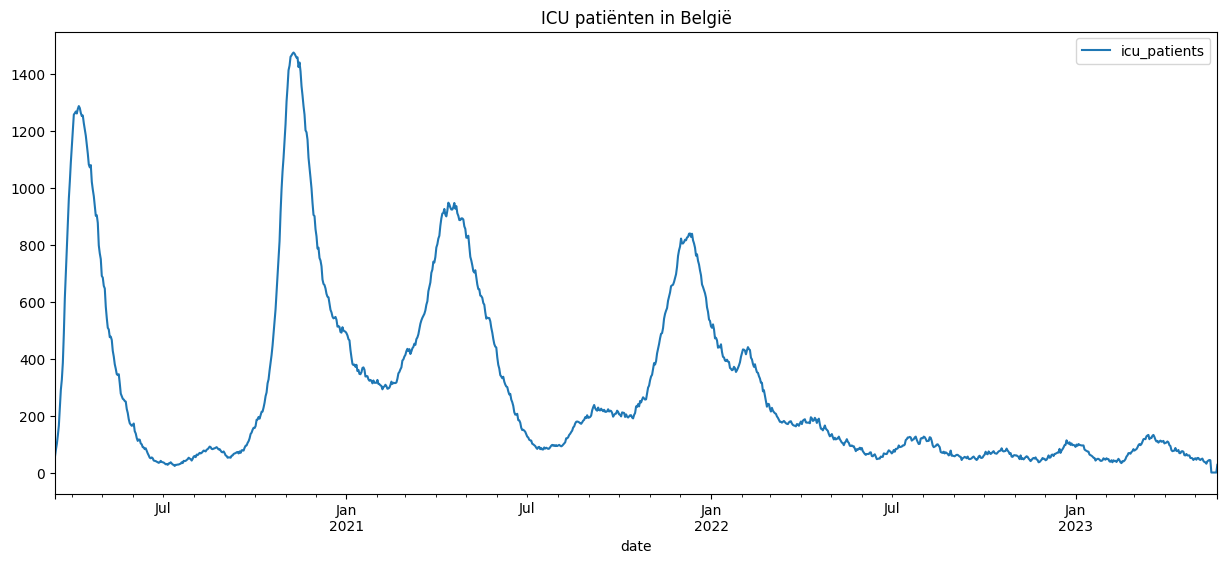

In [10]:
# Filter ICU en verwijder NaN
icu_be = covid19[covid19['location'] == 'Belgium'][['icu_patients']].dropna()

# Plot
icu_be.plot(figsize=(15, 6), title='ICU patiënten in België')
plt.show()

Build a duible exponential smoothing (Holt) model of this time series. Make a forecast of 70 time units and plot the observations, fitted values and forecast.

Are we currently in an upward or downward trend, according to this model? Do the forecasted values seem reasonable if you look at the last period?

/home/seppevo/repo/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


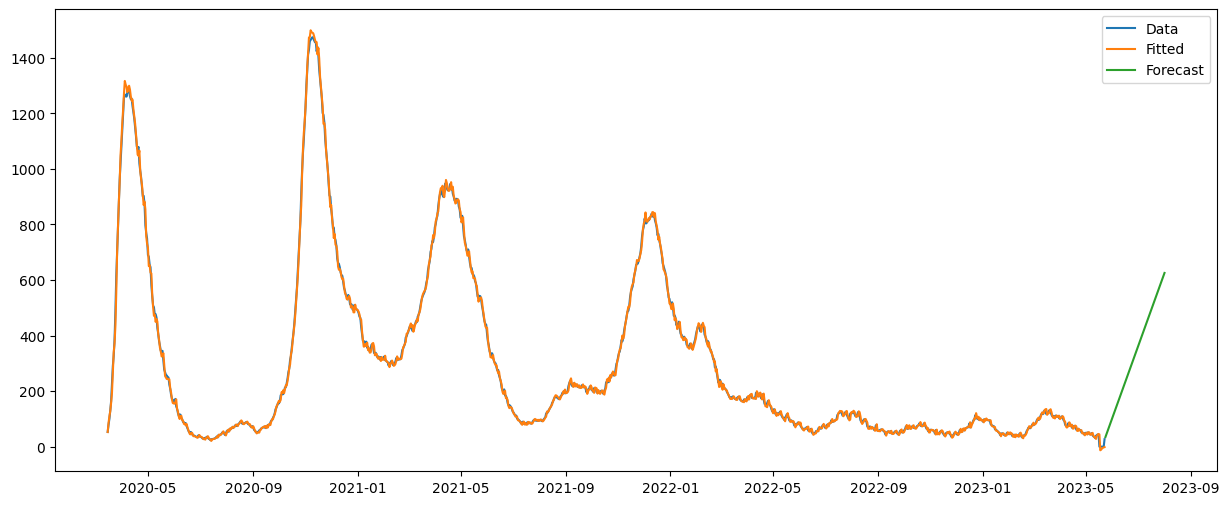

In [11]:
# Holt model
model_holt = ExponentialSmoothing(icu_be['icu_patients'], trend='add', seasonal=None)
fit_holt = model_holt.fit()

# Voorspelling 70 dagen
icu_forecast = fit_holt.forecast(70)

# Plot
plt.figure(figsize=(15, 6))
plt.plot(icu_be, label='Data')
plt.plot(fit_holt.fittedvalues, label='Fitted')
plt.plot(icu_forecast, label='Forecast')
plt.legend()
plt.show()


Since we didn't set any initial parameters like $\alpha$ and $\beta$, the model calculated them using some rule of thumb. List these parameters from the model:

In [12]:
# Model parameters
print(fit_holt.params['smoothing_level']) # alpha
print(fit_holt.params['smoothing_trend']) # beta

0.9616981892119923
0.3669574010526316


What were the final estimated values for the level and trend, that are used in the forecast? In other words, what are the parameters of the line that estimates future observations?

In [13]:
# Niveau en trend
print(f"Level: {fit_holt.level.iloc[-1]}, Trend: {fit_holt.trend.iloc[-1]}")

Level: 25.902777562119468, Trend: 8.563826307243634


Let's try to set the parameters ourselves. Recreate the Holt-model with $\alpha = \beta = 0.1$. Calculate a forecast like before and plot.

In [14]:
# Holt model met eigen parameters
model_manual = ExponentialSmoothing(icu_be['icu_patients'], trend='add').fit(smoothing_level=0.1, smoothing_trend=0.1)
# Plot en vergelijk...

/home/seppevo/repo/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Compare the model parameters and final estimates. Which of the two forecast models seems to perform best if you look at the plots?